In [7]:
# Core libraries for analysis, visualization and clustering
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.cluster import KMeans          # K-Means clustering algorithm
from sklearn.preprocessing import StandardScaler  # Feature scaling

# Load cleaned dataset produced in 01_EDA.ipynb
df = pd.read_csv('../data/hyg_clean.csv')
print(df.shape)

(107859, 38)


In [8]:
# Apply log10 transforms — same reasoning as notebook 04
# Log scale compresses the enormous luminosity range into a meaningful spread
df['log_lum'] = np.log10(df['lum'])
df['log_temp'] = np.log10(df['temp'])

# Select only the two features needed for clustering
# dropna() removes any rows where either feature is missing
features = df[['log_temp', 'log_lum']].dropna()

# Scale features to mean=0, std=1 using StandardScaler
# Critical for K-Means — without scaling, log_lum (range ~10) would dominate
# over log_temp (range ~0.8) simply due to larger numerical values
# After scaling both features contribute equally to distance calculations
scaler = StandardScaler()
X_scaled = scaler.fit_transform(features)

# Verify scaling worked — both features should have mean ≈ 0 and std ≈ 1
print(X_scaled.shape)
print(f"log_temp mean: {X_scaled[:,0].mean():.4f}, std: {X_scaled[:,0].std():.4f}")
print(f"log_lum mean: {X_scaled[:,1].mean():.4f}, std: {X_scaled[:,1].std():.4f}")

(107859, 2)
log_temp mean: -0.0000, std: 1.0000
log_lum mean: -0.0000, std: 1.0000


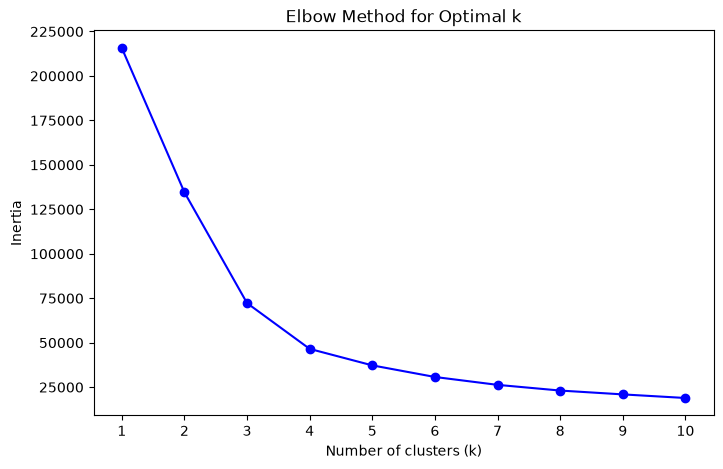

In [9]:
# Elbow method: run K-Means for k=1 to 10 and record inertia at each k
# Inertia = sum of squared distances from each point to its cluster centre
# Lower inertia = tighter, better defined clusters
inertias = []
k_range = range(1, 11)

for k in k_range:
    # random_state=42 ensures reproducible results across runs
    # n_init=10 runs K-Means 10 times with different starting points
    # and keeps the best result — avoids getting stuck in local optima
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertias.append(kmeans.inertia_)

# Plot inertia vs k — look for the "elbow" where improvement flattens
# Elbow at k=4 indicates 4 natural clusters in the data
plt.figure(figsize=(8, 5))
plt.plot(k_range, inertias, 'bo-')
plt.xlabel('Number of clusters (k)')
plt.ylabel('Inertia')
plt.title('Elbow Method for Optimal k')
plt.xticks(k_range)
plt.show()

In [10]:
# Fit final K-Means model with optimal k=4 identified from elbow method
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
kmeans.fit(X_scaled)

# Add cluster labels to features DataFrame
# labels_ contains a cluster assignment (0-3) for every star
df_clustered = features.copy()
df_clustered['cluster'] = kmeans.labels_

# Check cluster sizes — unequal sizes are physically meaningful
# small clusters indicate rare stellar populations
print(df_clustered['cluster'].value_counts())

cluster
3    41195
2    36169
0    24455
1     6040
Name: count, dtype: int64


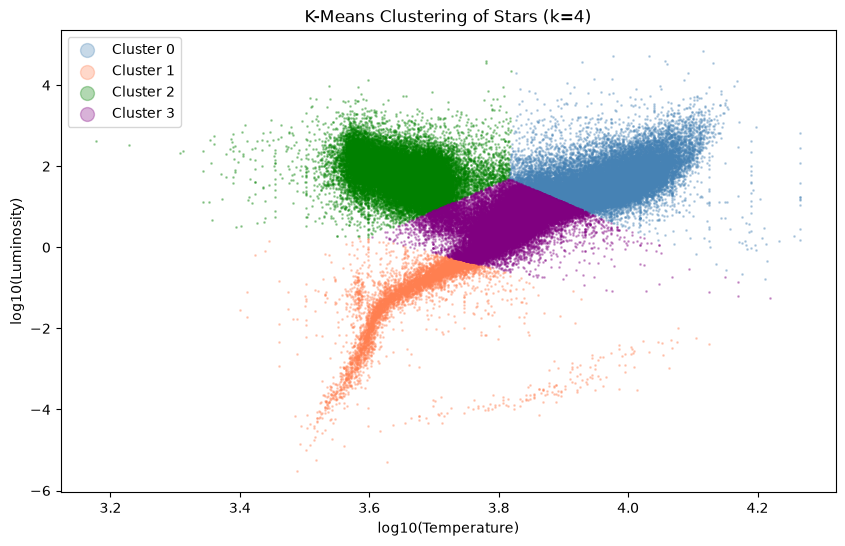

In [11]:
# Plot each cluster in a different colour on the HR diagram axes
# s=1 and alpha=0.3 keep 107,000 points readable without blobbing
# markerscale=10 enlarges legend markers since scatter points are tiny
colors = ['steelblue', 'coral', 'green', 'purple']

plt.figure(figsize=(10, 6))
for i in range(4):
    # Create boolean mask to select only stars in cluster i
    mask = df_clustered['cluster'] == i
    plt.scatter(df_clustered[mask]['log_temp'],
                df_clustered[mask]['log_lum'],
                c=colors[i], s=1, alpha=0.3, label=f'Cluster {i}')

plt.xlabel('log10(Temperature)')
plt.ylabel('log10(Luminosity)')
plt.title('K-Means Clustering of Stars (k=4)')
plt.legend(markerscale=10)
plt.show()

## Conclusion

To find the optimal number of clusters, we ran K-Means across k values 
from 1 to 10 on the full scaled dataset. For each iteration, the inertia 
was recorded and plotted against k. The resulting elbow curve showed a 
clear inflection point at k=4, where the rate of improvement in cluster 
tightness began to flatten significantly.

The four clusters align with distinct regions in log temperature and log 
luminosity space. Cluster 2 (green) captures cool but highly luminous 
stars, consistent with red giants sitting in the upper right of the HR 
diagram. The remaining three clusters subdivide the main sequence by 
temperature zone: cool red dwarfs at the dim end, Sun-like stars in the 
middle, and hot blue stars at the bright end.

The subdivision of the main sequence into three zones rather than one 
unified cluster is the most interesting finding here. It suggests that 
the temperature gradient along the main sequence carries a stronger 
statistical signal than the giant versus main sequence boundary. This 
also connects directly back to the bimodal temperature distribution 
observed in notebook 02. The two peaks we identified there correspond 
to the natural density variations along the main sequence that K-Means 
independently rediscovered here.